In [1]:
# THIS CODE USES NUMPY; FOR FEWER THAN 500 GRIDPOINTS
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from PIL import Image
from numba import jit, prange

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
from scipy.signal import find_peaks
from scipy.integrate import quad
from scipy.optimize import root_scalar
from matplotlib.animation import PillowWriter, FuncAnimation
import ipywidgets as widgets
from IPython.display import display

print("Fin")

Fin


In [2]:
# Independent parameters (free to edit)

Na = 0.5 # Units: M 
T = 303.15 # Units: K
valence = 4
duration = 250 * 10**5 # In timesteps of dt
gridpoints = 128 # Number of points
dx = 10 # Units: nm
dt = 1.E-5 # Units: sec
rho_mean = 9E-5 # Initial mean density of nanostar A, found by spinodal (rho dense + rho dilute)/2 for the value of T used
save_interval = 10**5

grid_length = dx * gridpoints # Total length (nm)
inv_dx2 = 1.0 / (dx * dx)

# Establishes constants
K = 1.0E6 # Units: nm^5 
M = 1 # Units: (nm s)^-1
B2 = 2190 # Units: nm^3
vb = 1.66 # Units: nm^3
kB = 1.314E-23 * 0.24 # Units: cal/K (1J=0.24cal)
mol = 6.02E23
dHa = -42000 # Units: cal/mol 
dS1 = 1.84 * np.log(Na) # Units: cal/mol K
dS0 = -120 # Units: cal/mol K at 1M NaCl
floor = 1E-12 # Minimum value for arrays
num_saves = duration // save_interval + 1 # Number of saved values

Da = vb * np.exp(-(dHa - T * (dS0 + dS1)) / (mol * kB * T))
Db = Da

print("Fin")

Fin


In [3]:
# Initializes array of density values
np.random.seed(7) # Opens a random number generator instance, seed 7

rho_A = rho_mean * (1.0 + 0.01 * np.random.uniform(low=-1, high=1, size=(gridpoints, gridpoints))) # Creates rho values around the mean with slight randomness
rho_A = np.maximum(rho_A, 1.E-10) # Prevents negative densities
rho_B = rho_mean * (1.0 + 0.01 * np.random.uniform(low=-1, high=1, size=(gridpoints, gridpoints))) 
rho_B = np.maximum(rho_B, 1.E-10) 
rho_AB = rho_mean * (1.0 + 0.01 * np.random.uniform(low=-1, high=1, size=(gridpoints, gridpoints))) 
rho_AB = np.maximum(rho_AB, 1.E-10) 

initial_mass = np.sum(rho_A) + np.sum(rho_B) + np.sum(rho_AB)
n = rho_A.shape[0]

@jit(nopython=True, cache=False) # Converts the given function into machine code (optimization) and tries to parallelize
def laplacian_2d(function_array):
    """
    Computes the 2D Laplacian of a function, given an array representing that function
    """
    # Note: np.roll with axis= is unsupported in Numba nopython mode
    # Periodic boundary conditions are implemented via explicit modular indexing
    result = np.empty_like(function_array)
    for i in range(n):
        for j in range(n):
            result[i, j] = (
                function_array[i, (j+1) % n] - 2.0 * function_array[i, j] + function_array[i, (j-1) % n] +  # x-axis neighbors
                function_array[(i+1) % n, j] - 2.0 * function_array[i, j] + function_array[(i-1) % n, j]    # y-axis neighbors
            ) * inv_dx2
    return result


@jit(nopython=True, parallel=True, cache=False) # Converts the given function into machine code (optimization) and tries to parallelize
def compute_step_three(rho_A, rho_B, rho_AB):
    
    # Total chemical potential (with floored rho, Xa)
    rho = rho_A + rho_B + rho_AB
            
    Xa = (-1 + np.sqrt(1 + 4 * valence*(rho_A+0.5*rho_AB)*Da)) / (2 * valence*(rho_A+0.5*rho_AB)*Da) 
    Xb = (-1 + np.sqrt(1 + 4 * valence*(rho_B+0.5*rho_AB)*Db)) / (2 * valence*(rho_A+0.5*rho_AB)*Db) 
            
    beta_mu_total_A = (2.0 * B2 * rho + np.log(rho_A) +               # beta mu_ref
                      valence * np.log(Xa) -                          # beta mu_b
                      K * laplacian_2d(rho_A))                        # beta mu_int
    beta_mu_total_B = (2.0 * B2 * rho + np.log(rho_B) +               # beta mu_ref
                      valence * np.log(Xb) -                          # beta mu_b
                      K * laplacian_2d(rho_B))                        # beta mu_int
    beta_mu_total_AB = (2.0 * B2 * rho + np.log(rho_AB) +             # beta mu_ref
                      valence/2 * (np.log(Xa) + np.log(Xb)) -         # beta mu_b
                      K * laplacian_2d(rho_AB))                       # beta mu_int

    # Updates the density explicitly: rho(t+dt) = rho(t) + dt * M laplacian (beta mu_total)
    rho_A_step = dt * M * laplacian_2d(beta_mu_total_A)
    rho_B_step = dt * M * laplacian_2d(beta_mu_total_B)
    rho_AB_step = dt * M * laplacian_2d(beta_mu_total_AB)

    return(rho_A_step, rho_B_step, rho_AB_step)

print("Fin")

Fin


In [4]:
# Initializes arrays for saving rho
num_saves = duration // save_interval + 1

rho_A_total_array = np.zeros((num_saves, gridpoints, gridpoints)) # Third dimension added for 2D grid
rho_B_total_array = np.zeros((num_saves, gridpoints, gridpoints))
rho_AB_total_array = np.zeros((num_saves, gridpoints, gridpoints))

rho_A_total_array[0] = rho_A
rho_B_total_array[0] = rho_B
rho_AB_total_array[0] = rho_AB

save_index = 1

# Tracks the mass over time to ensure conservation
mass_history = []
time_history = []


for step in range(duration):

    # Iterates to find new value of rho
    rho_A_step, rho_B_step, rho_AB_step = compute_step_three(rho_A, rho_B, rho_AB)
    rho_A += rho_A_step
    rho_B += rho_B_step
    rho_AB += rho_AB_step

    # Adds the new density to the array of densities + checks mass conservation every 10^6 steps
    if step % (save_interval) == 0:
        rho_A_total_array[save_index] = rho_A
        rho_B_total_array[save_index] = rho_B
        rho_AB_total_array[save_index] = rho_AB
        save_index += 1

        total_mass = np.sum(rho_A) + np.sum(rho_B) + np.sum(rho_AB)

        mass_history.append(total_mass)
        time_history.append(step * dt)

        rho_A = np.maximum(rho_A, floor)        
        rho_B = np.maximum(rho_B, floor)
        rho_AB = np.maximum(rho_AB, floor)


        print(f"Progress: {(step/(save_interval))} out of {duration/(save_interval)}")

Progress: 0.0 out of 250.0
Progress: 1.0 out of 250.0
Progress: 2.0 out of 250.0
Progress: 3.0 out of 250.0
Progress: 4.0 out of 250.0
Progress: 5.0 out of 250.0
Progress: 6.0 out of 250.0
Progress: 7.0 out of 250.0
Progress: 8.0 out of 250.0
Progress: 9.0 out of 250.0
Progress: 10.0 out of 250.0
Progress: 11.0 out of 250.0
Progress: 12.0 out of 250.0
Progress: 13.0 out of 250.0
Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/home/nehadesigar/my_env/lib/python3.12/site-packages/numba/core/serialize.py", line 30, in _numba_unpickle
    def _numba_unpickle(address, bytedata, hashed):
    
KeyboardInterrupt

The above exception was the direct cause of the following exception:

SystemError: <function _numba_unpickle at 0x7fe384f10720> returned a result with an exception set

The above exception was the direct cause of the following exception:

SystemError: <function _numba_unpickle at 0x7fe384f10720> returned a result with an exception set

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/nehadesigar/my_env/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3748, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_900132/4006376744.py", line 22, in <module>
    rho_A_step, rho_B_step, rho_AB_step = compute_step_three(rho_A, rho_B, rho_AB)
      

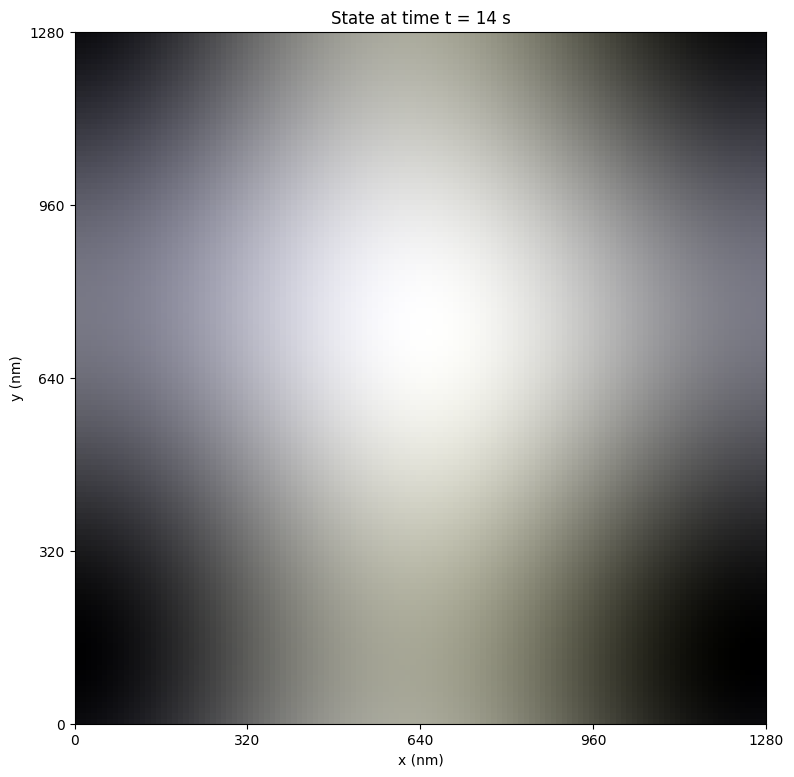

In [5]:
normalized_A = (rho_A - np.min(rho_A)) / (np.max(rho_A) - np.min(rho_A))
normalized_B = (rho_B - np.min(rho_B)) / (np.max(rho_B) - np.min(rho_B))
normalized_AB = (rho_AB - np.min(rho_AB)) / (np.max(rho_AB) - np.min(rho_AB))

rgb_image = np.dstack((normalized_A, normalized_B, normalized_AB))
t_final = (save_index - 1) * save_interval * dt

plt.figure(figsize=(8, 8))
plt.imshow(rgb_image, extent=[0, grid_length, 0, grid_length], origin='lower')
plt.title(f"State at time t = {t_final:.0f} s")
plt.xlabel("x (nm)")
plt.ylabel("y (nm)")
plt.xticks([0, grid_length/4, grid_length/2, (3*grid_length)/4, grid_length])
plt.yticks([0, grid_length/4, grid_length/2, (3*grid_length)/4, grid_length])

plt.tight_layout()
plt.savefig("rho_final.png", dpi=150)
plt.show()